# Pipeline GAIE — Previsão de Desmatamento (end-to-end)
**FIAP · Global Solution 2026 · Indústria Espacial · Generative AI for Engineering**

Camada de IA preditiva de um produto de observação da Terra por satélite. A partir de
indicadores ambientais do **World Bank** (derivados de sensoriamento remoto — Landsat/MODIS/
Sentinel), prevemos a **variação da cobertura florestal** do próximo ciclo (regressão) e o
**risco de desmatamento** (classificação), interpretados com **SHAP**. **ODS 13 — Ação Climática.**

Este notebook executa todas as etapas: dados → EDA → pré-processamento/engenharia de atributos →
treino e comparação de modelos → validação → interpretabilidade (SHAP).

In [1]:
import os, sys
from pathlib import Path

# Garante a raiz do projeto como diretorio de trabalho (funciona rodando de notebooks/ ou da raiz)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Image, display
pd.set_option("display.width", 120); pd.set_option("display.max_columns", 40)
print("ROOT:", ROOT)

ROOT: C:\Users\muril\GenAI - GS


## 1. Dados — World Bank Indicators API (dados reais)

In [2]:
from data_loader import load_data, INDICATOR_NAMES
df_raw = load_data()
print("Fonte: World Bank Indicators API (real) | shape:", df_raw.shape,
      "| paises:", df_raw["iso3"].nunique(), "| anos:", (df_raw.year.min(), df_raw.year.max()))
df_raw.head()

2026-06-06 19:36:09,082 [INFO] Buscando dados reais no World Bank API...


2026-06-06 19:36:15,237 [INFO] Codigos do World Bank utilizados: {'forest_area_km2': 'AG.LND.FRST.K2', 'forest_area_pct': 'AG.LND.FRST.ZS', 'agri_land_pct': 'AG.LND.AGRI.ZS', 'arable_land_pct': 'AG.LND.ARBL.ZS', 'urban_pop_pct': 'SP.URB.TOTL.IN.ZS', 'pop_density': 'EN.POP.DNST', 'population': 'SP.POP.TOTL', 'gdp_per_capita': 'NY.GDP.PCAP.CD', 'co2_per_capita': 'EN.GHG.CO2.PC.CE.AR5', 'renewable_energy_pct': 'EG.FEC.RNEW.ZS', 'pm25_pollution': 'EN.ATM.PM25.MC.M3', 'land_area_km2': 'AG.LND.TOTL.K2'}


2026-06-06 19:36:15,238 [INFO] World Bank OK: 4991 linhas.


2026-06-06 19:36:15,283 [INFO] Painel salvo em C:\Users\muril\GenAI - GS\data\raw\worldbank_panel.csv


Fonte: World Bank Indicators API (real) | shape: (4991, 17) | paises: 217 | anos: (np.int64(2000), np.int64(2022))


,iso3,country,region,income,year,forest_area_km2,forest_area_pct,agri_land_pct,arable_land_pct,urban_pop_pct,pop_density,population,gdp_per_capita,co2_per_capita,renewable_energy_pct,pm25_pollution,land_area_km2
0,ABW,Aruba,Latin America & Caribbean,High income,2000,4.2,2.333333,11.111111,11.111111,65.354550,503.266667,90588,20681.023027,2.968384,0.2,NaN,180.0
1,ABW,Aruba,Latin America & Caribbean,High income,2001,4.2,2.333333,11.111111,11.111111,65.335114,507.994444,91439,20740.132583,2.973567,0.2,NaN,180.0
2,ABW,Aruba,Latin America & Caribbean,High income,2002,4.2,2.333333,11.111111,11.111111,65.282069,511.522222,92074,21307.248251,3.225666,0.2,NaN,180.0
3,ABW,Aruba,Latin America & Caribbean,High income,2003,4.2,2.333333,11.111111,11.111111,65.198292,517.377778,93128,21949.485996,3.676660,0.2,NaN,180.0
4,ABW,Aruba,Latin America & Caribbean,High income,2004,4.2,2.333333,11.111111,11.111111,65.088653,528.544444,95138,23700.631990,3.672560,0.2,NaN,180.0


## 2. Análise exploratória (EDA)

In [3]:
# Percentual de valores ausentes por indicador (antes da imputacao)
miss = (df_raw[INDICATOR_NAMES].isna().mean() * 100).round(1).sort_values(ascending=False)
print("% de valores ausentes por indicador:")
print(miss)
df_raw[INDICATOR_NAMES].describe().T[["mean", "std", "min", "max"]]

% de valores ausentes por indicador:
pm25_pollution          15.8
co2_per_capita           6.5
arable_land_pct          5.8
renewable_energy_pct     5.8
agri_land_pct            4.0
gdp_per_capita           3.1
forest_area_km2          2.8
forest_area_pct          2.8
pop_density              1.9
land_area_km2            1.9
population               0.0
urban_pop_pct            0.0
dtype: float64


,mean,std,min,max
forest_area_km2,1.933323e+05,7.546884e+05,0.000000,8.153120e+06
forest_area_pct,3.235891e+01,2.454407e+01,0.000000,9.557721e+01
agri_land_pct,3.726472e+01,2.235475e+01,0.436116,8.548737e+01
arable_land_pct,1.380937e+01,1.360681e+01,0.043141,6.414688e+01
urban_pop_pct,5.913942e+01,2.412094e+01,8.043814,1.000000e+02
pop_density,4.099992e+02,1.874133e+03,0.136492,2.153000e+04
population,3.256741e+07,1.295320e+08,9544.000000,1.425423e+09
gdp_per_capita,1.579618e+04,2.447425e+04,109.593814,2.260520e+05
co2_per_capita,4.894229e+00,8.921026e+00,0.000000,2.028652e+02
renewable_energy_pct,2.985094e+01,2.953471e+01,0.000000,9.830000e+01


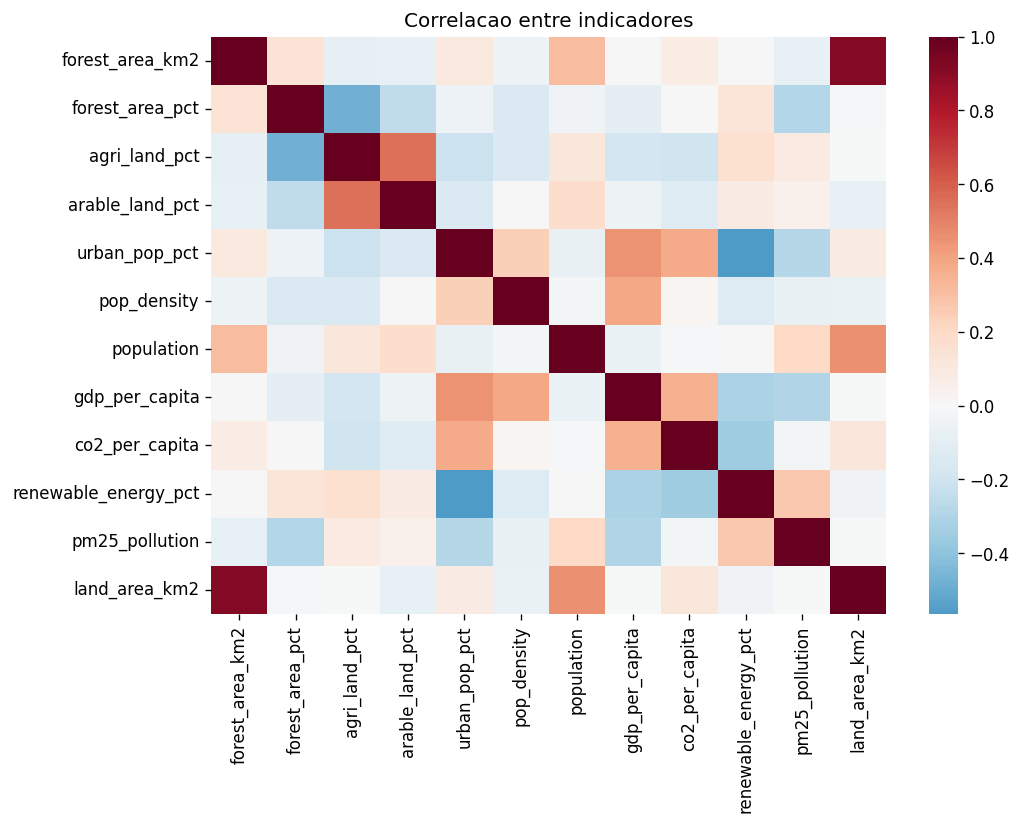

In [4]:
# Mapa de correlacao entre indicadores
plt.figure(figsize=(9, 7))
sns.heatmap(df_raw[INDICATOR_NAMES].corr(numeric_only=True), annot=False, cmap="RdBu_r", center=0)
plt.title("Correlacao entre indicadores")
plt.tight_layout(); plt.savefig("reports/figures/eda_correlation.png", dpi=120, bbox_inches="tight"); plt.close()
display(Image("reports/figures/eda_correlation.png"))

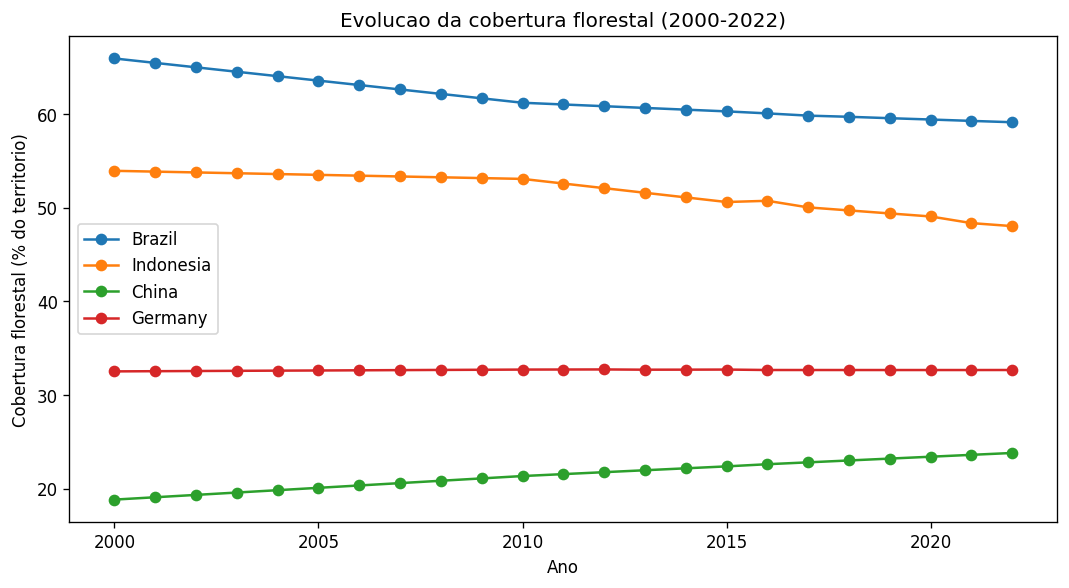

In [5]:
# Evolucao da cobertura florestal para alguns paises
exemplos = [c for c in ["Brazil", "Indonesia", "China", "Germany"] if c in df_raw["country"].unique()][:4]
plt.figure(figsize=(9, 5))
for c in exemplos:
    sub = df_raw[df_raw["country"] == c].sort_values("year")
    plt.plot(sub["year"], sub["forest_area_pct"], marker="o", label=c)
plt.xlabel("Ano"); plt.ylabel("Cobertura florestal (% do territorio)")
plt.title("Evolucao da cobertura florestal (2000-2022)"); plt.legend()
plt.tight_layout(); plt.savefig("reports/figures/eda_forest_trend.png", dpi=120, bbox_inches="tight"); plt.close()
display(Image("reports/figures/eda_forest_trend.png"))

## 3. Pré-processamento, engenharia de atributos e alvos

In [6]:
from preprocessing import preprocess, get_feature_columns, TARGET_COLS
data = preprocess()
numeric, categorical = get_feature_columns(data)
modeling = data.dropna(subset=TARGET_COLS).reset_index(drop=True)
print("Dataset processado:", data.shape, "| modelaveis:", len(modeling))
print("Features:", len(numeric), "numericas +", len(categorical), "categoricas")
print("\nDistribuicao das classes (target_clf):"); print(modeling["target_clf"].value_counts())
print("\nAlvo de regressao (target_reg, % a.a.):"); print(modeling["target_reg"].describe().round(3))
modeling[[*numeric[:6], "target_reg", "target_clf"]].head()

2026-06-06 19:36:15,778 [INFO] Painel bruto carregado de C:\Users\muril\GenAI - GS\data\raw\worldbank_panel.csv (4991 linhas).


2026-06-06 19:36:16,074 [INFO] Dataset processado salvo em C:\Users\muril\GenAI - GS\data\processed\dataset.csv


Dataset processado: (4991, 36) | modelaveis: 4686
Features: 29 numericas + 2 categoricas

Distribuicao das classes (target_clf):
target_clf
Estável              2723
Desmatamento Alto    1108
Recuperação           855
Name: count, dtype: int64

Alvo de regressao (target_reg, % a.a.):
count    4686.000
mean       -0.056
std         0.938
min       -17.396
25%        -0.280
50%         0.000
75%         0.099
max        12.000
Name: target_reg, dtype: float64


,year,forest_area_km2,forest_area_pct,agri_land_pct,arable_land_pct,urban_pop_pct,target_reg,target_clf
0,2000,4.2,2.333333,11.111111,11.111111,65.354550,0.0,Estável
1,2001,4.2,2.333333,11.111111,11.111111,65.335114,0.0,Estável
2,2002,4.2,2.333333,11.111111,11.111111,65.282069,0.0,Estável
3,2003,4.2,2.333333,11.111111,11.111111,65.198292,0.0,Estável
4,2004,4.2,2.333333,11.111111,11.111111,65.088653,0.0,Estável


## 4. Treino e comparação de modelos

Validação: split temporal (teste em anos > 2016) + GroupKFold por país.

In [7]:
import train
reg_results, best_reg = train.run_regression(modeling, numeric, categorical)
print("Melhor regressor:", best_reg)
reg_results

2026-06-06 19:36:16,417 [INFO] === Regressão ===


2026-06-06 19:36:16,586 [INFO] LinearRegression   CV R2=0.049 | test R2=-0.189 RMSE=0.827


2026-06-06 19:36:21,768 [INFO] RandomForest       CV R2=0.387 | test R2=0.756 RMSE=0.374


2026-06-06 19:36:31,291 [INFO] GradientBoosting   CV R2=0.287 | test R2=0.734 RMSE=0.391


2026-06-06 19:36:33,538 [INFO] XGBoost            CV R2=0.306 | test R2=0.715 RMSE=0.405


Melhor regressor: RandomForest


,model,cv_r2_mean,cv_r2_std,test_r2,test_mae,test_rmse
0,RandomForest,0.387103,0.145163,0.756379,0.130917,0.374226
1,GradientBoosting,0.286885,0.189003,0.734222,0.192201,0.390873
2,XGBoost,0.305514,0.177582,0.715307,0.157432,0.404543
3,LinearRegression,0.048950,0.312953,-0.189481,0.355572,0.826904


In [8]:
clf_results, best_clf, encoder = train.run_classification(modeling, numeric, categorical)
print("Melhor classificador:", best_clf)
clf_results

2026-06-06 19:36:33,784 [INFO] === Classificação ===


2026-06-06 19:36:34,319 [INFO] LogisticRegression CV F1=0.748 | test acc=0.869 F1=0.808 AUC=0.952


2026-06-06 19:36:37,733 [INFO] RandomForest       CV F1=0.712 | test acc=0.954 F1=0.939 AUC=0.986


2026-06-06 19:37:06,363 [INFO] GradientBoosting   CV F1=0.816 | test acc=0.956 F1=0.943 AUC=0.989


2026-06-06 19:37:12,235 [INFO] XGBoost            CV F1=0.801 | test acc=0.966 F1=0.956 AUC=0.988



Relatório de classificação (melhor modelo, conjunto de teste):
                   precision    recall  f1-score   support

Desmatamento Alto       0.97      0.96      0.97       238
          Estável       0.98      0.97      0.97       690
      Recuperação       0.90      0.95      0.93       137

         accuracy                           0.97      1065
        macro avg       0.95      0.96      0.96      1065
     weighted avg       0.97      0.97      0.97      1065

Melhor classificador: XGBoost


,model,cv_f1_macro_mean,cv_f1_macro_std,test_accuracy,test_f1_macro,test_roc_auc_ovr
0,XGBoost,0.800759,0.028709,0.966197,0.955797,0.988500
1,GradientBoosting,0.816066,0.055281,0.955869,0.942833,0.989107
2,RandomForest,0.711547,0.044835,0.953991,0.938939,0.986109
3,LogisticRegression,0.748135,0.018374,0.868545,0.807976,0.951626


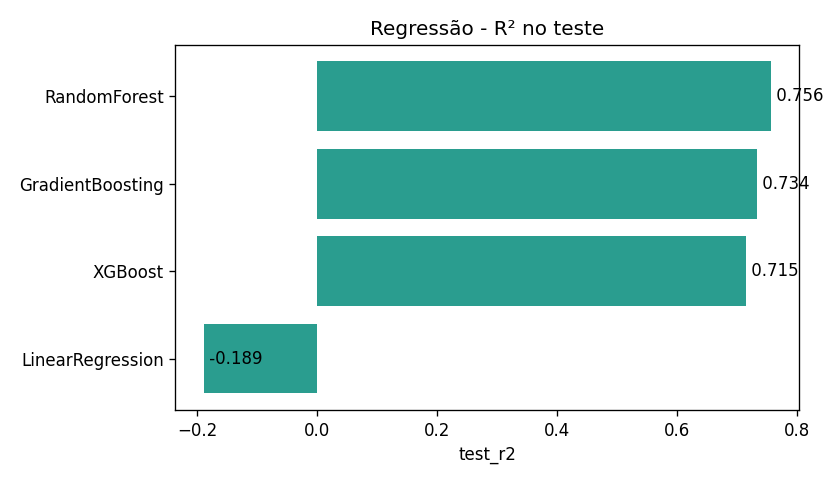

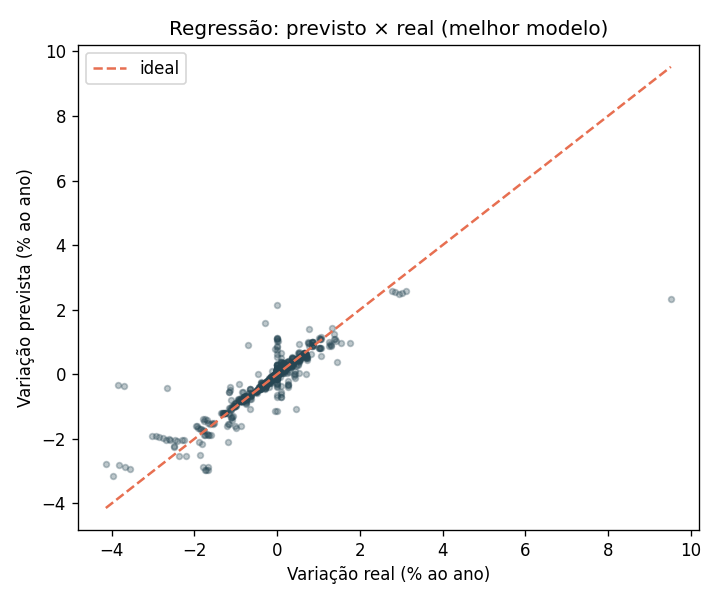

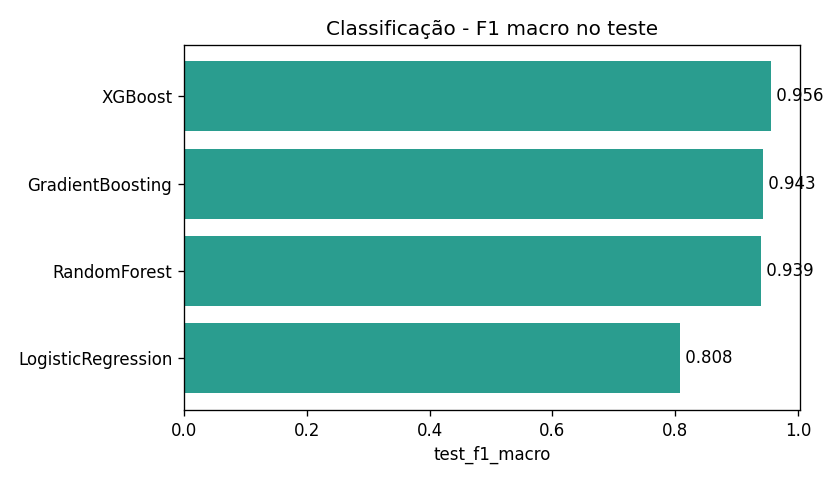

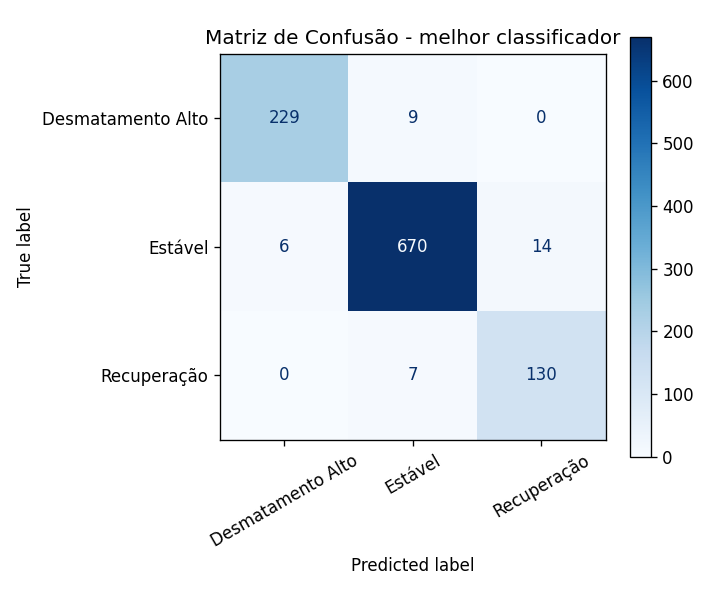

In [9]:
# Figuras de comparacao e matriz de confusao
for f in ["regression_comparison", "regression_scatter", "classification_comparison", "confusion_matrix"]:
    p = f"reports/figures/{f}.png"
    if os.path.exists(p):
        display(Image(p))

## 5. Interpretabilidade com SHAP

C:\Users\muril\GenAI - GS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


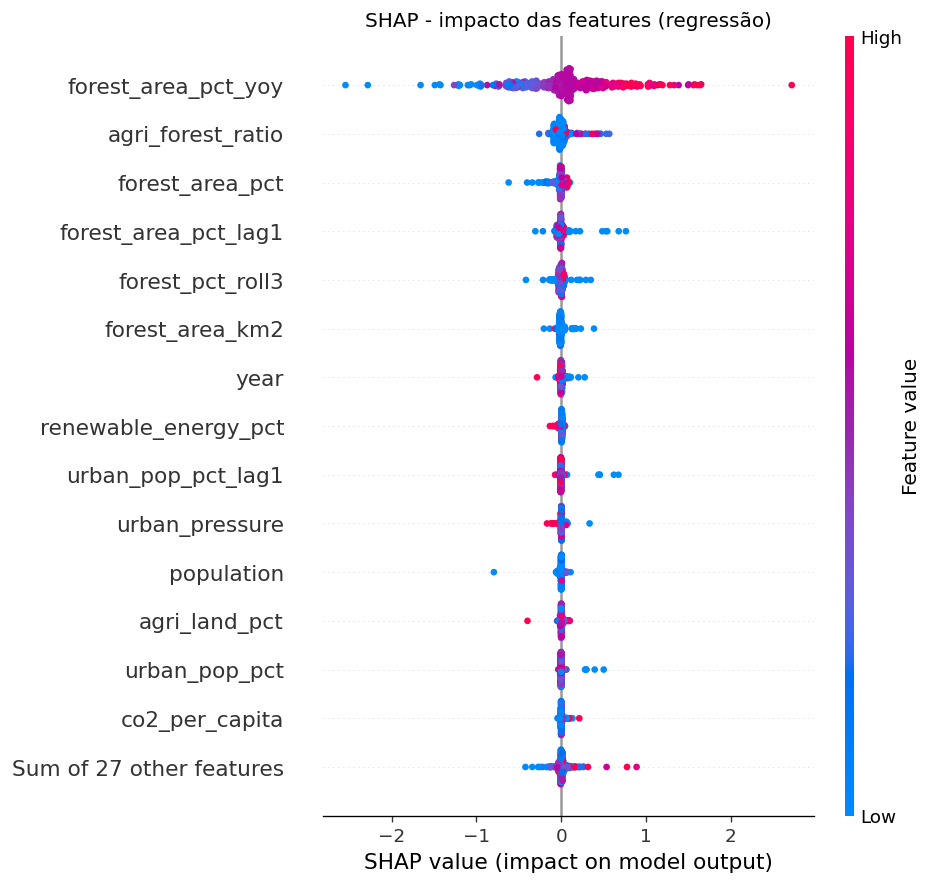

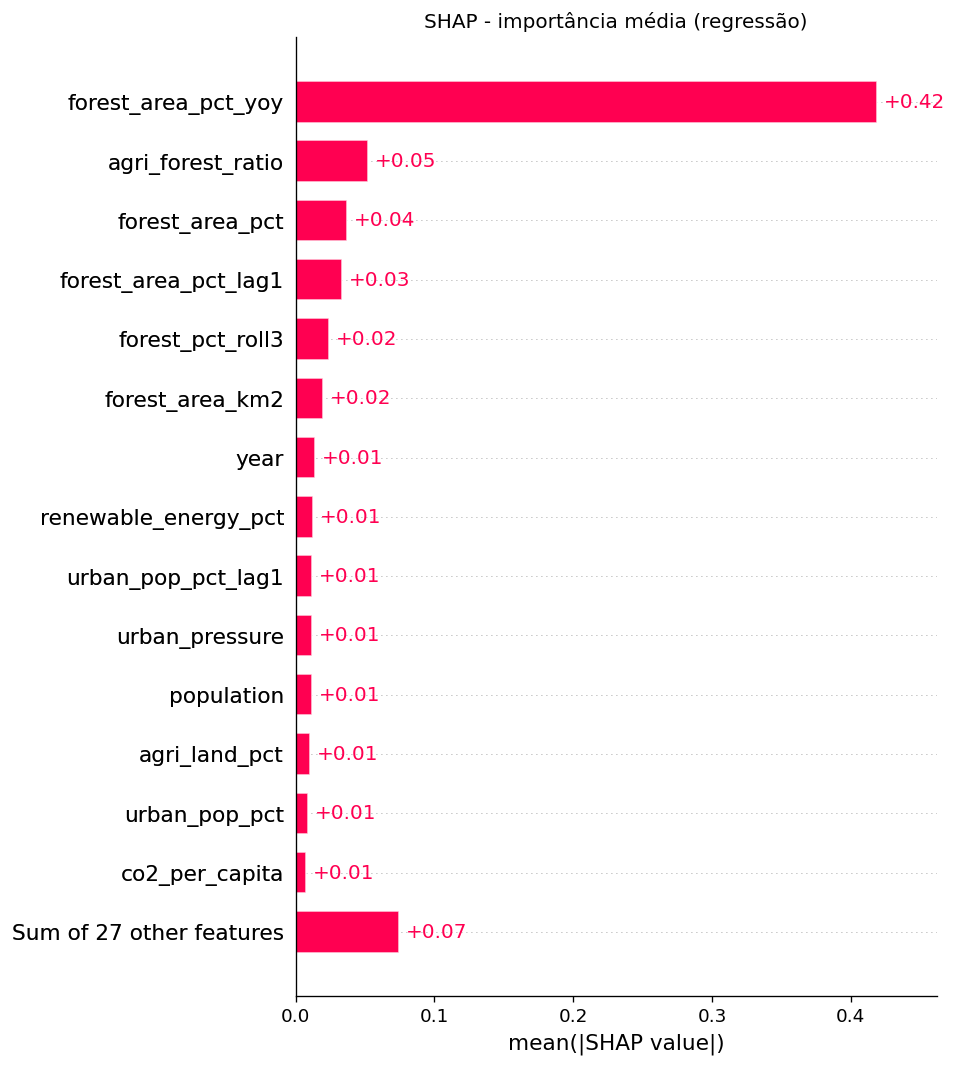

In [10]:
import joblib, explain
reg = joblib.load("models/best_regressor.joblib")
meta = joblib.load("models/metadata.joblib")
sample = modeling[numeric + categorical].sample(min(400, len(modeling)), random_state=42)
paths = explain.save_global_regression_shap(reg, sample)
display(Image(str(paths["beeswarm"]))); display(Image(str(paths["bar"])))

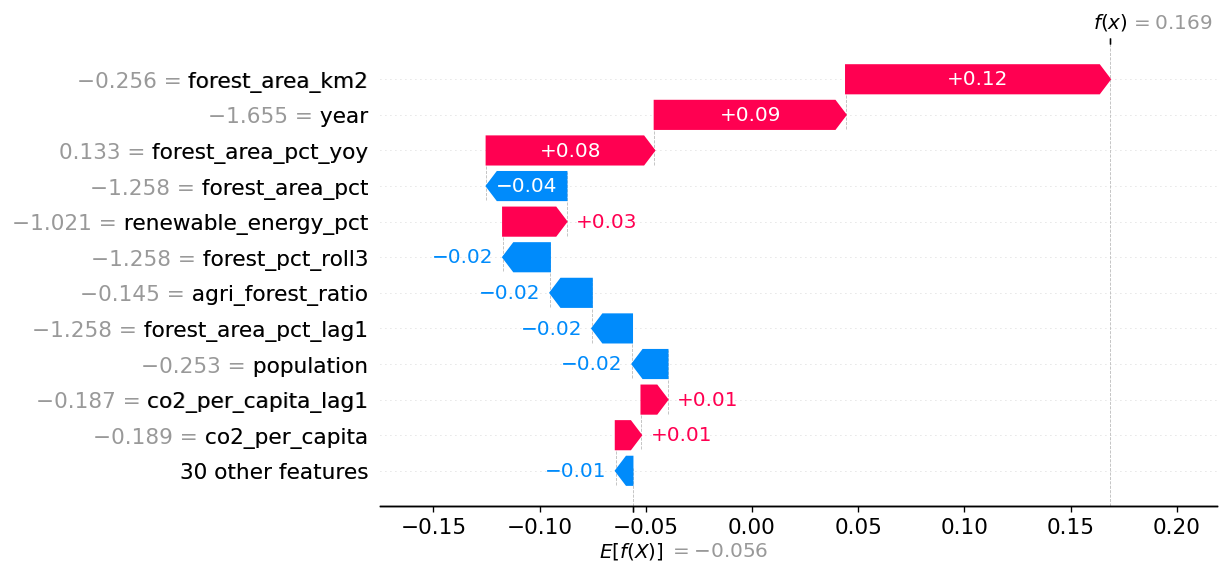

In [11]:
# Explicacao LOCAL (uma observacao) - mesmo grafico usado no app
expl = explain.explain_instance(reg, modeling[numeric + categorical].iloc[[0]])
import shap
shap.plots.waterfall(expl, max_display=12, show=False)
fig = plt.gcf(); fig.set_size_inches(9, 5)
fig.savefig("reports/figures/shap_local_example.png", dpi=120, bbox_inches="tight"); plt.close(fig)
display(Image("reports/figures/shap_local_example.png"))

## 6. Conclusão

- **Dados reais** do World Bank (observação da Terra por satélite): ~5.000 linhas, 217 países, 12 indicadores.
- **Engenharia de atributos** (lags, variações YoY, médias móveis, razões de pressão) elevou o poder preditivo.
- **Regressão:** RandomForest foi o melhor (R² de teste ≈ 0,76); o modelo linear falhou (R² < 0),
  evidenciando a natureza **não-linear** do problema.
- **Classificação:** XGBoost foi o melhor (acurácia ≈ 0,97, F1-macro ≈ 0,96, ROC-AUC ≈ 0,99).
- **SHAP** mostrou que a tendência recente da floresta, a cobertura atual e a média móvel são os
  fatores mais influentes — coerente com o domínio.
- A solução é entregue como **dashboard Streamlit** (deploy no Hugging Face Spaces), conectando a
  observação espacial à **Ação Climática (ODS 13)**.